GLOBAL IMPORTS AND CONFIGS

In [1]:
import os

import os
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import (

    KMeans,

    DBSCAN,

    AgglomerativeClustering
)

from sklearn.decomposition import PCA

ARRAY_PATH = "processed_arrays/"

MODEL_PATH = "models/"

IMAGE_PATH = "images/"

os.makedirs(MODEL_PATH, exist_ok=True)

os.makedirs(IMAGE_PATH, exist_ok=True)

LOADING THE PREPROCESSED FULL DATA

In [2]:
X_full = np.load(

    os.path.join(
        ARRAY_PATH,
        "X_full.npy"
    ),

    allow_pickle=True
)

y_full = np.load(

    os.path.join(
        ARRAY_PATH,
        "y_full.npy"
    ),

    allow_pickle=True
)

feature_names = np.load(

    os.path.join(
        ARRAY_PATH,
        "feature_names.npy"
    ),

    allow_pickle=True
)

print("Dataset Shape:")

print(X_full.shape)

Dataset Shape:
(1000, 19)


VISUALIZING THE DATA WITH PCA

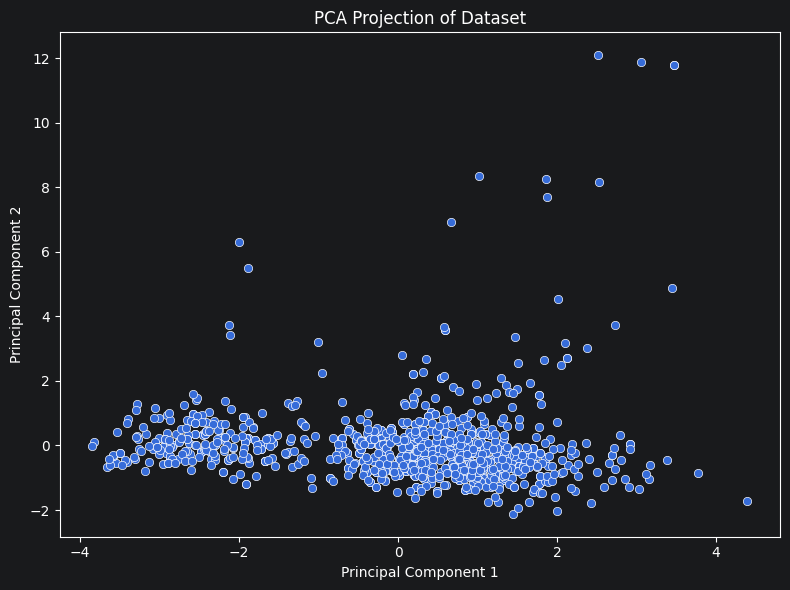

In [3]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_full
)

plt.figure(figsize=(8, 6))

sns.scatterplot(

    x=X_pca[:, 0],

    y=X_pca[:, 1]
)

plt.title("PCA Projection of Dataset")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.show()

# CLUSTERING MODELS

### K MEANS ELBOW CLUSTERING METHOD

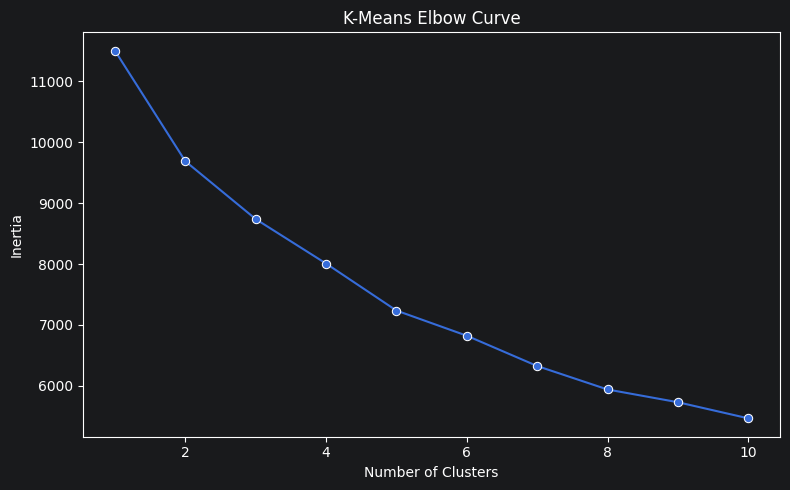

In [4]:
inertia_values = []

cluster_range = range(1, 11)

for k in cluster_range:

    kmeans_temp = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )

    kmeans_temp.fit(X_full)

    inertia_values.append(
        kmeans_temp.inertia_
    )

plt.figure(figsize=(8, 5))

sns.lineplot(

    x=list(cluster_range),

    y=inertia_values,

    marker="o"
)

plt.title("K-Means Elbow Curve")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "kmeans_elbow_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [5]:
kmeans_model = KMeans(

    n_clusters=3,

    random_state=42,

    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(
    X_full
)

print("K-Means Training Complete")

joblib.dump(

    kmeans_model,

    os.path.join(
        MODEL_PATH,
        "kmeans_model.joblib"
    )
)

K-Means Training Complete


['models/kmeans_model.joblib']

CLUSTER VISUALIZATION

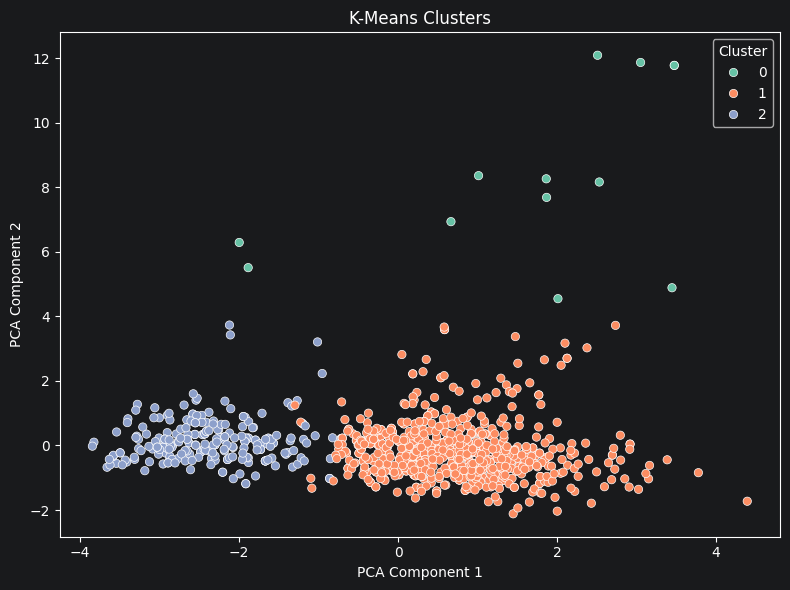

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(

    x=X_pca[:, 0],

    y=X_pca[:, 1],

    hue=kmeans_labels,

    palette="Set2"
)

plt.title("K-Means Clusters")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "kmeans_clusters.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

### HIERARCHICAL CLUSTERING METHOD

In [7]:
hierarchical_model = AgglomerativeClustering(

    n_clusters=3,

    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_full
)

np.save(

    os.path.join(
        MODEL_PATH,
        "hierarchical_labels.npy"
    ),

    hierarchical_labels
)

VISUALIZING HIERARCHICAL CLUSTERS

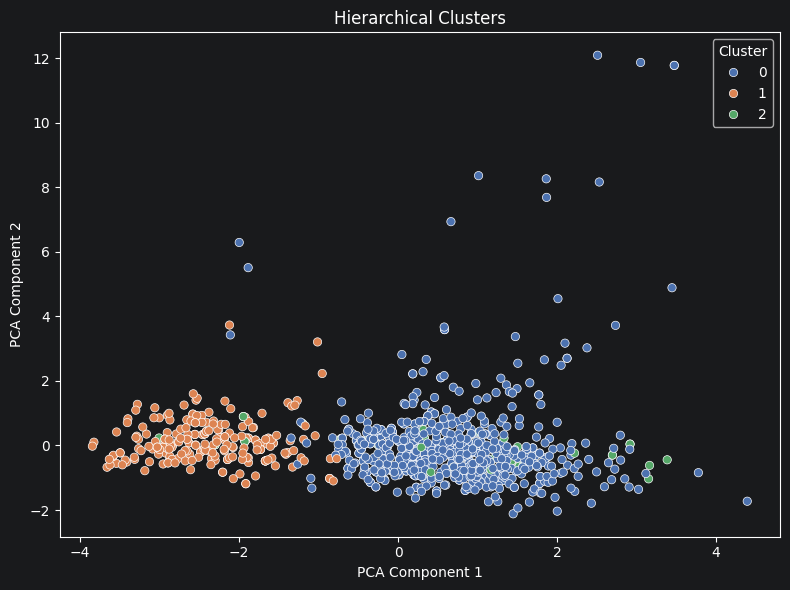

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(

    x=X_pca[:, 0],

    y=X_pca[:, 1],

    hue=hierarchical_labels,

    palette="deep"
)

plt.title("Hierarchical Clusters")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "hierarchical_clusters.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

### DBSCAN CLUSTERING METHOD

In [ ]:
dbscan_model = DBSCAN(

    eps=1.5,

    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(
    X_full
)

np.save(

    os.path.join(
        MODEL_PATH,
        "dbscan_labels.npy"
    ),

    dbscan_labels
)

unique_clusters = np.unique(
    dbscan_labels
)

print("Unique DBSCAN Clusters:")

print(unique_clusters)